# 🧠 STROKE PREDICTION ANALYSIS PROJECT
(Stroke Prediction Analysis Project)

## 📝 Overview
This notebook provides a detailed walkthrough of the entire pipeline, from Data Cleaning and Exploratory Data Analysis (EDA) to Mathematical Feature Engineering for the Stroke Prediction Dataset.

The core objective of this project is to extract in-depth insights from demographic, health, and lifestyle indicators, thereby establishing a solid mathematical foundation for an AI pipeline to predict patients' stroke risks.

## 🛠️ Libraries Used in this Notebook:
NumPy: For multi-dimensional array processing, and optimizing linear and algebraic computations from scratch.

Pandas: For manipulating, cleaning, aggregating, and transforming DataFrame structures.

Matplotlib / Seaborn: For visualizing distribution plots, correlation matrices, and statistical metrics.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

filepath = '../data/raw/healthcare-dataset-stroke-data.csv'
df = pd.read_csv(filepath)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [37]:
from src.numpy_tasks import *
filepath = '../data/raw/healthcare-dataset-stroke-data.csv'
matrix_data = q1_load_and_clean_data(filepath)


--- Q1: Data Loading & Cleaning ---
Shape: (5110, 3)
Dtype: float64



# Module 1: Numpy

In [38]:
q2_compute_statistics(matrix_data)

--- Q2: Basic Statistics ---
Age -> Mean: 43.23, Median: 45.00, Std: 22.61
Avg_Glucose_Level -> Mean: 106.15, Median: 91.88, Std: 45.28
BMI -> Mean: 28.89, Median: 28.40, Std: 7.70



--- Q5: Correlation Matrix ---
[[1.         0.23817111 0.32594247]
 [0.23817111 1.         0.16875135]
 [0.32594247 0.16875135 1.        ]] 



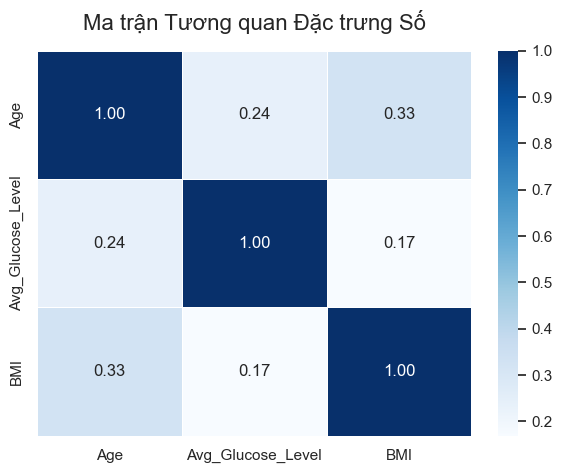

In [39]:
# In kết quả ma trận số
q5_correlation_matrix(matrix_data)
corr_matrix = np.corrcoef(matrix_data, rowvar=False)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=.5,
            xticklabels=['Age', 'Avg_Glucose_Level', 'BMI'], 
            yticklabels=['Age', 'Avg_Glucose_Level', 'BMI'])
plt.title('Ma trận Tương quan Đặc trưng Số', fontsize=16, pad=15)
plt.show()

--- Q9: Manual PCA ---
Projected Data Shape: (5110, 2)
First 2 projected records:
 [[ 2.61982949 -1.54379378]
 [ 1.56766683 -1.62711011]] 



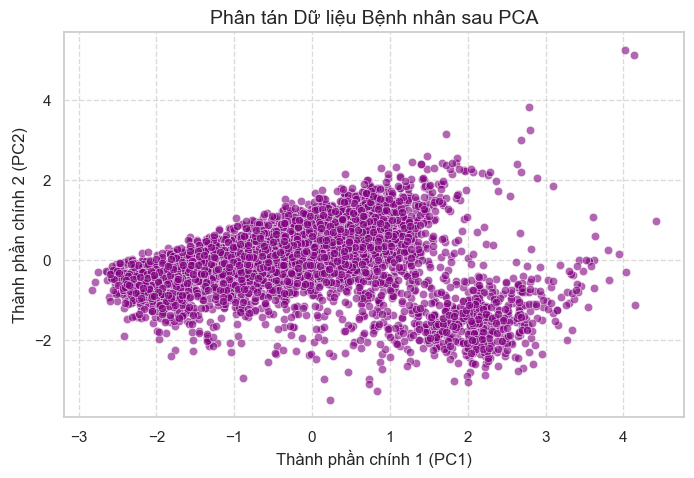

In [40]:
# 1. Chạy hàm PCA và in kết quả chữ
pca_result = q9_manual_pca(matrix_data)

# 2. Vẽ biểu đồ phân tán
plt.figure(figsize=(8, 5))
x_pca = pca_result[:, 0]
y_pca = pca_result[:, 1]

sns.scatterplot(x=x_pca, y=y_pca, alpha=0.6, color='purple')
plt.title('Phân tán Dữ liệu Bệnh nhân sau PCA', fontsize=14)
plt.xlabel('Thành phần chính 1 (PC1)')
plt.ylabel('Thành phần chính 2 (PC2)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Module 2: Math

In [41]:
from src.math_tasks import *
filepath = '../data/raw/healthcare-dataset-stroke-data.csv'
df_math = load_data(filepath)

--- Q1: Matrix Representation ---
Matrix Shape: (5110, 3)
Matrix Rank: 3

--- Q2: Linear Regression (Normal Equation) ---
Weights (b, w1, w2): [-0.0839252   0.00215857  0.00037067]

--- Q3: Base and Conditional Probabilities ---
P(stroke=1): 0.0487
P(stroke=1 | hypertension=1): 0.1325

--- Q5: Variance and Covariance ---
Variance of avg_glucose_level: 2050.20
Covariance between glucose and age: 243.88

--- Q9: Bayes' Theorem with Discretization ---
P(stroke | glucose_bin):
glucose_bin
Normal         0.035771
Prediabetic    0.037794
Diabetic       0.100000
Name: stroke, dtype: float64 

--- Q4: Compute Gradient of MSE ---
Gradient with respect to W: [ 1.13194950e-16  1.17983466e-15 -5.81504838e-15]

--- Q6: Covariance Matrix & Eigen Decomposition ---
Covariance Matrix:
 [[1.00019573 0.23821773 0.32600627]
 [0.23821773 1.00019573 0.16878438]
 [0.32600627 0.16878438 1.00019573]]
Eigenvalues:
 [1.49469606 0.66284554 0.8430456 ]
Eigenvectors:
 [[ 0.6313054   0.75442772  0.17970061]
 [ 0.505

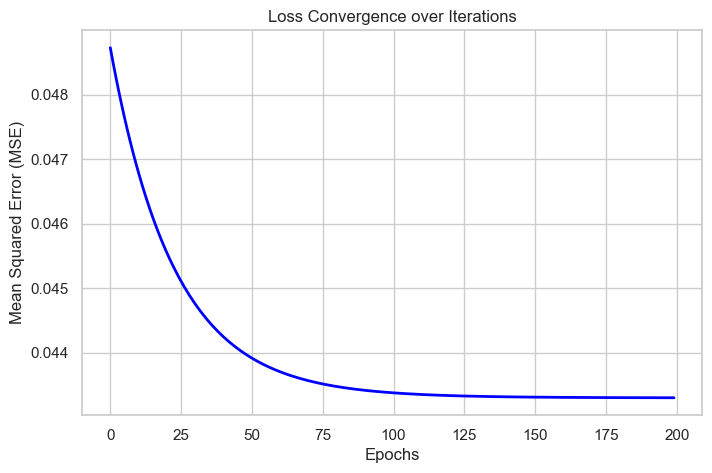

In [42]:
X_num = q1_matrix_representation(df_math)
X_b, y, w_optimal = q2_linear_regression(df_math)
q3_probabilities(df_math)
q5_variance_covariance(df_math)
q9_bayes_theorem(df_math)
q4_gradient_mse(X_b, y, w_optimal)
q6_covariance_eigen(X_num)
q7_svd(X_num)
q8_gradient_descent(X_b, y)
q10_regularization(X_b, y)

# Module 3: EDA with Pandas

In [43]:
from src.pandas_tasks import *

filepath = '../data/raw/healthcare-dataset-stroke-data.csv'

# Q1 & Q2: Tải dữ liệu, hiển thị cấu trúc và dọn dẹp các giá trị lỗi
df_pandas = q1_load_and_inspect(filepath)
df_pandas = q2_clean_dataset(df_pandas)

--- Q1: Load & Inspect Data ---
Head (first 2 rows):
       id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   

   stroke  
0       1  
1       1  

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married      


--- Q3: Group by Smoking Status ---
                 Total_Patients  Stroke_Rate
smoking_status                              
Unknown                    1544     0.030440
formerly smoked             884     0.079186
never smoked               1892     0.047569
smokes                      789     0.053232

--- Q4: Feature Engineering (Glucose to BMI Ratio) ---
Correlation between glucose_to_bmi_ratio and stroke: 0.0751

--- Q6: Pivot Table (Work Type vs Stroke) ---
stroke            0    1
work_type               
Govt_job        624   33
Never_worked     22    0
Private        2775  149
Self-employed   754   65
children        685    2

--- Q7: Age Groups Analysis ---
  age_group  stroke_rate
0     Child     0.002183
1     Adult     0.024230
2    Senior     0.135736

--- Q8: BMI Categories Analysis ---
  bmi_category  stroke_rate
0  Underweight     0.002967
1       Normal     0.028180
2   Overweight     0.071429
3        Obese     0.051042

--- Q5: Basic Visualizations (Saved to outpu

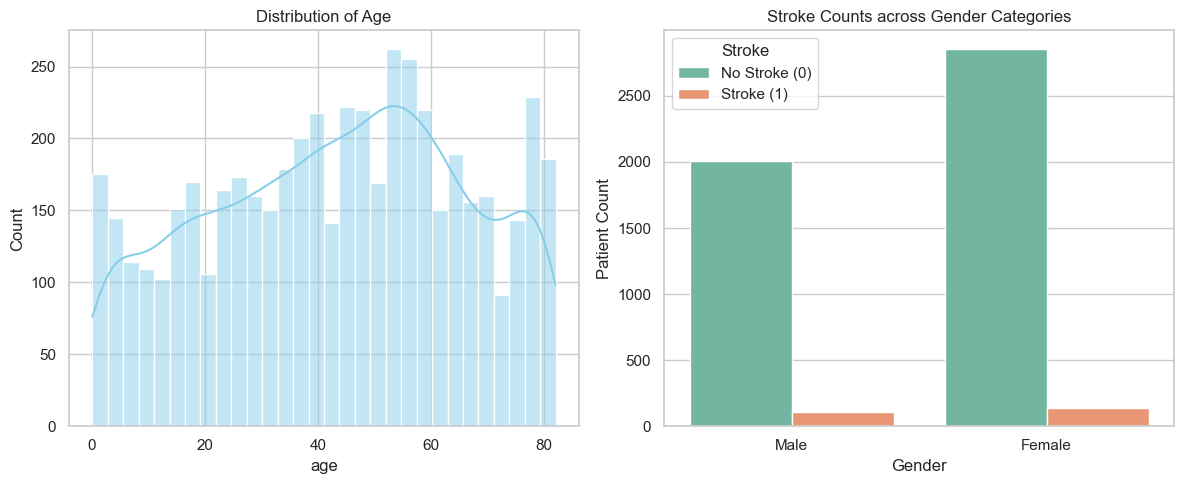

-> Saved: q5_age_stroke_dist.png

--- Q9: Advanced Visualizations (Saved to outputs/figures) ---


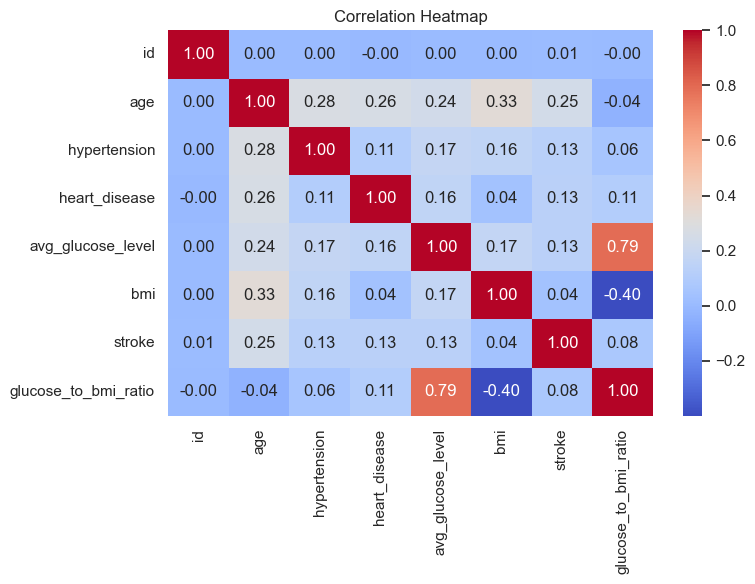

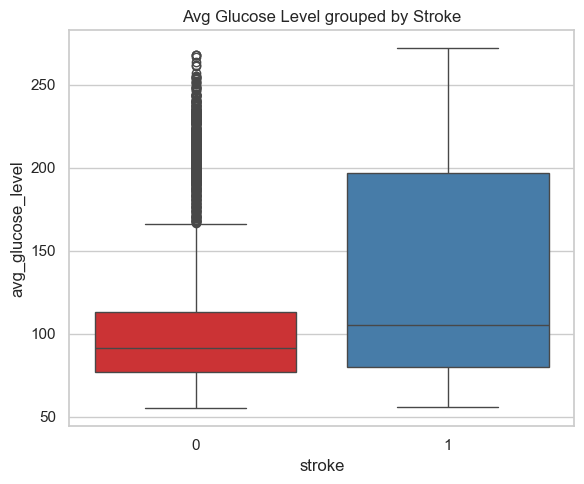

-> Saved: q9_correlation_heatmap.png and q9_glucose_boxplot.png

--- Q10: Feature Encoding (One-Hot Encoding) ---
Original columns count: 15
Encoded columns count: 20
Encoded features snippet:
 ['work_type_children', 'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']
-> Saved cleaned and encoded dataset to 'data/processed/stroke_data_cleaned_encoded.csv'


In [44]:
q3_group_smoking_status(df_pandas)
df_pandas = q4_glucose_bmi_ratio(df_pandas)
q6_pivot_table(df_pandas)
df_pandas = q7_age_groups(df_pandas)
df_pandas = q8_bmi_categories(df_pandas)
q5_basic_visualizations(df_pandas)
plt.show()
q9_advanced_visualizations(df_pandas)
plt.show()
q10_feature_encoding(df_pandas)

### 🎯 Project Insights & Pipeline Summary
Core Insights:

Age Risk Horizon: Statistical analysis and group testing clearly demonstrate that stroke risks are heavily concentrated within the elderly demographic (Senior). Incidents among youths or younger adults represent minor statistical anomalies.

Core Risk Factors (Hypertension & Glucose Anomalies): Leveraging Bayes' Theorem and Boxplot distributions, the data confirms that patients with a history of hypertension and diabetes (significantly elevated median blood glucose concentrations coupled with numerous outliers) face the highest stroke risk. These two variables serve as the most heavily weighted predictive features within the entire dataset.

Gender Neutrality: Correlation analysis and cross-tabulations indicate that gender has no significant impact on stroke probability. This variable is evenly distributed and does not create any structural risk disparity within this patient cohort.

### Preprocessing Readiness:

Data Cleaning: Successfully resolved structural missing values in the bmi feature using global statistical column averages (Mean Imputation) and eliminated minor noise/outlier records from the gender variable ("Other").

Encoding Optimization: Leveraged One-Hot Dummy Encoding configuration with multicollinearity mitigation (drop_first=True). All categorical dimensions have been transformed into numerical matrices, ensuring a 100% clean data pipeline ready for seamless integration into production Machine Learning classifiers.